In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense , Dropout
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

In [2]:
df= pd.read_csv(r'/content/Energy_consumption.csv')
df.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [3]:
df.shape

(1000, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB


In [5]:
df.describe()

,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873
std,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112
min,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690
50%,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696
75%,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742
max,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


In [7]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')

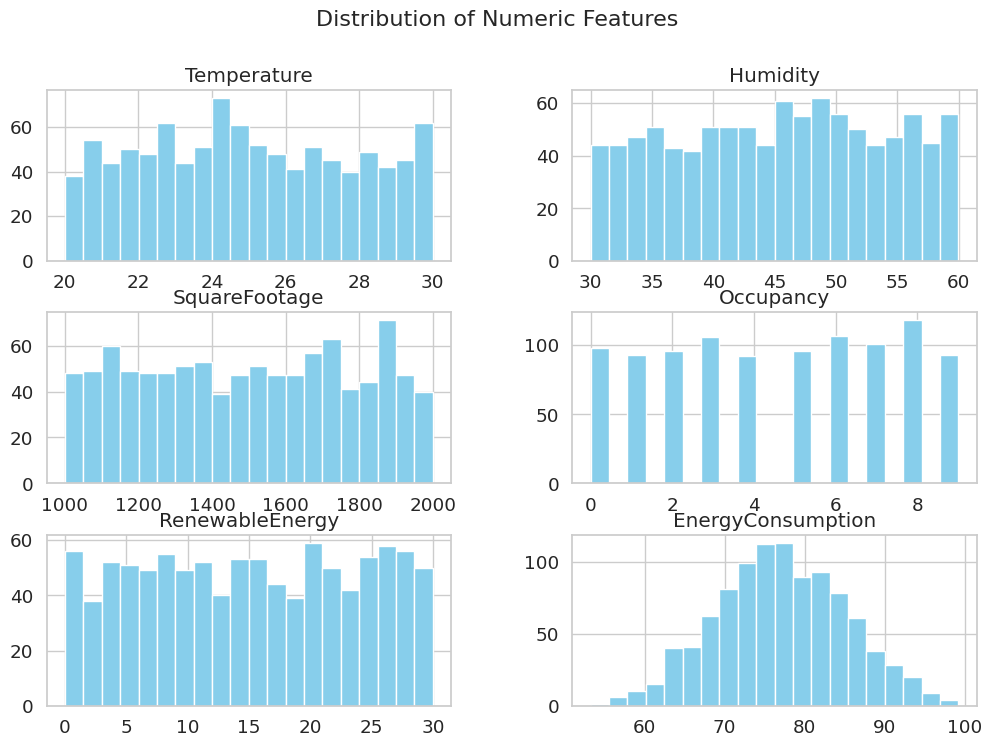

In [8]:
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

numeric_cols = ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy', 'EnergyConsumption']

df[numeric_cols].hist(figsize=(12, 8), bins=20, color='skyblue')
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()

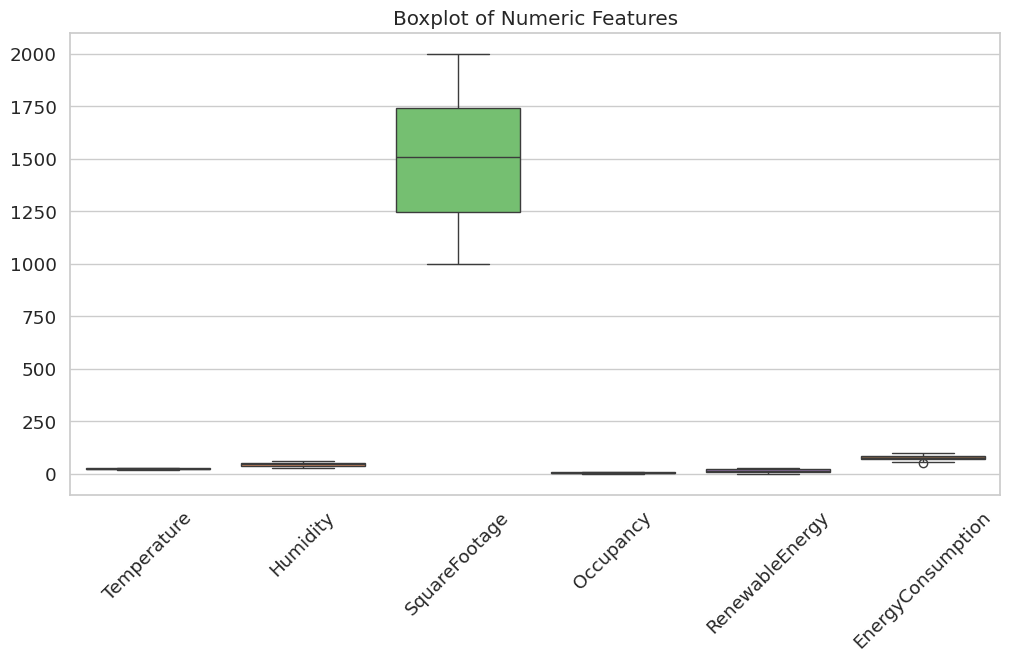

In [9]:

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.show()

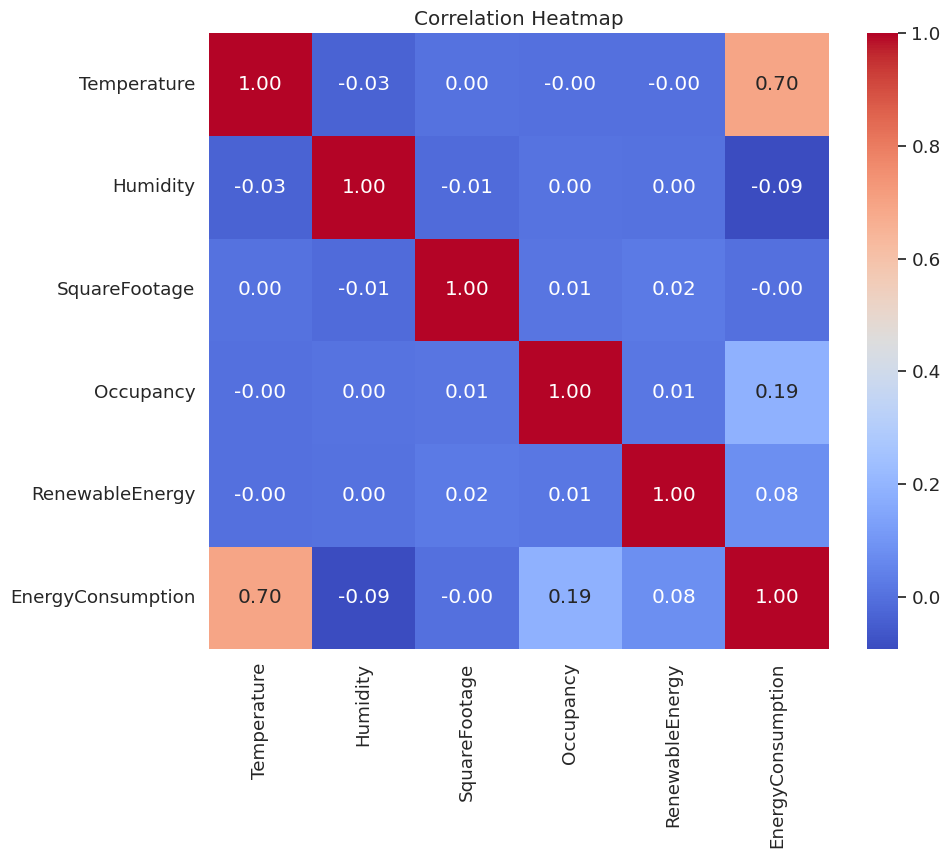

In [10]:

corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

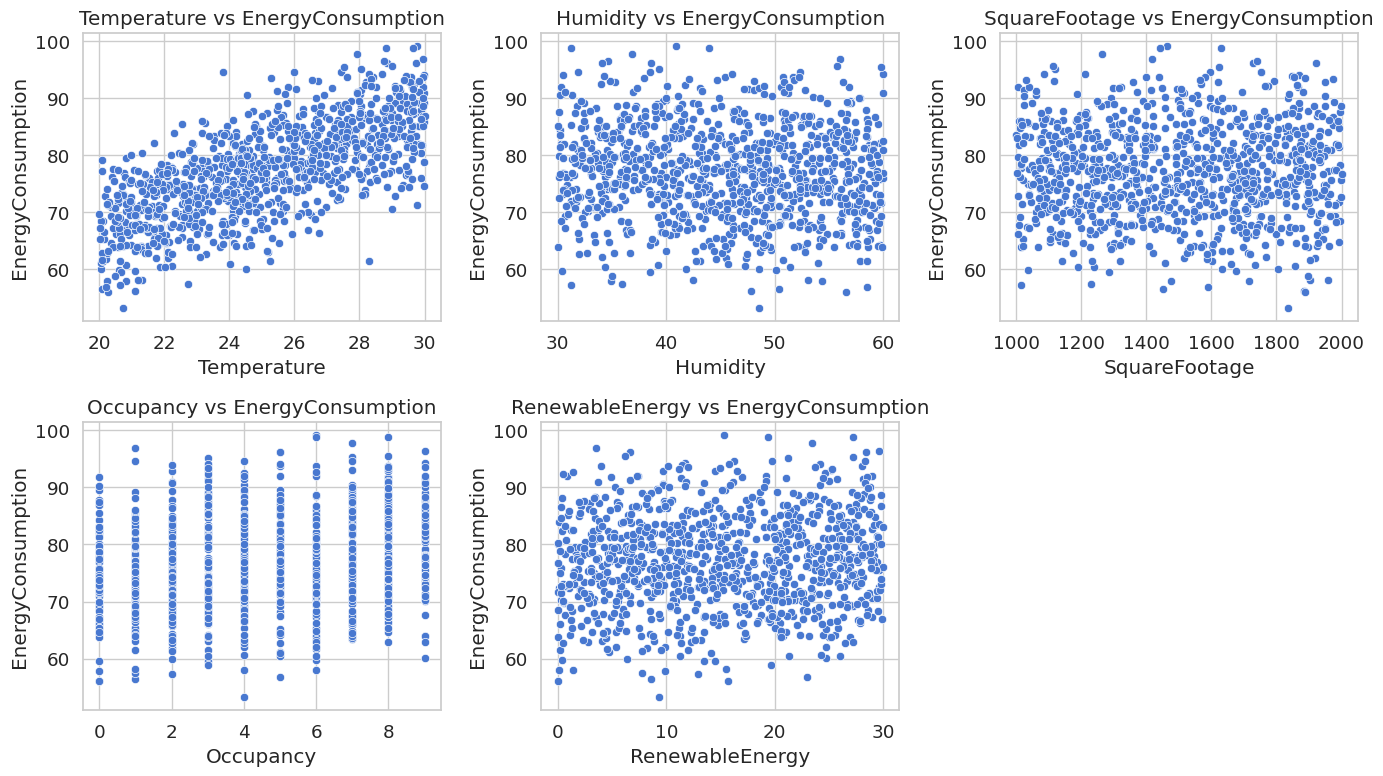

In [11]:

plt.figure(figsize=(14,8))
for i, col in enumerate(['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy']):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(x=df[col], y=df['EnergyConsumption'])
    plt.title(f"{col} vs EnergyConsumption")
plt.tight_layout()
plt.show()

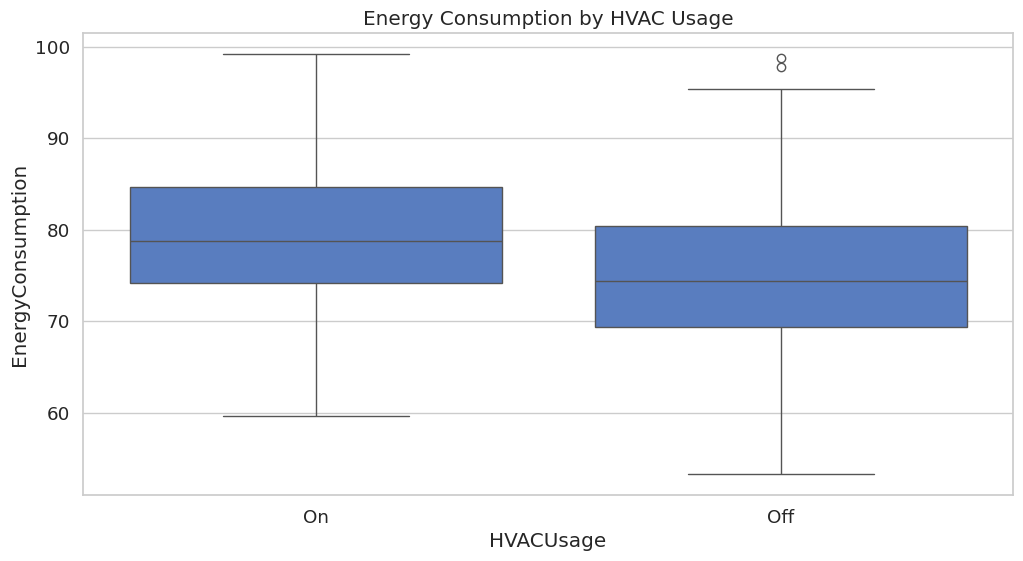

In [12]:

plt.figure(figsize=(12,6))
sns.boxplot(x='HVACUsage', y='EnergyConsumption', data=df)
plt.title("Energy Consumption by HVAC Usage")
plt.show()

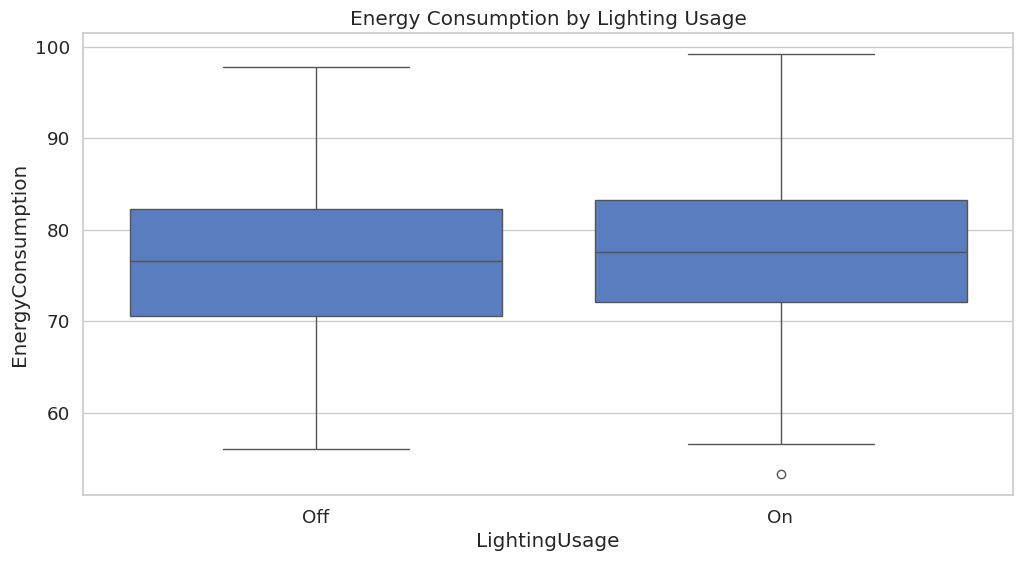

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(x='LightingUsage', y='EnergyConsumption', data=df)
plt.title("Energy Consumption by Lighting Usage")
plt.show()

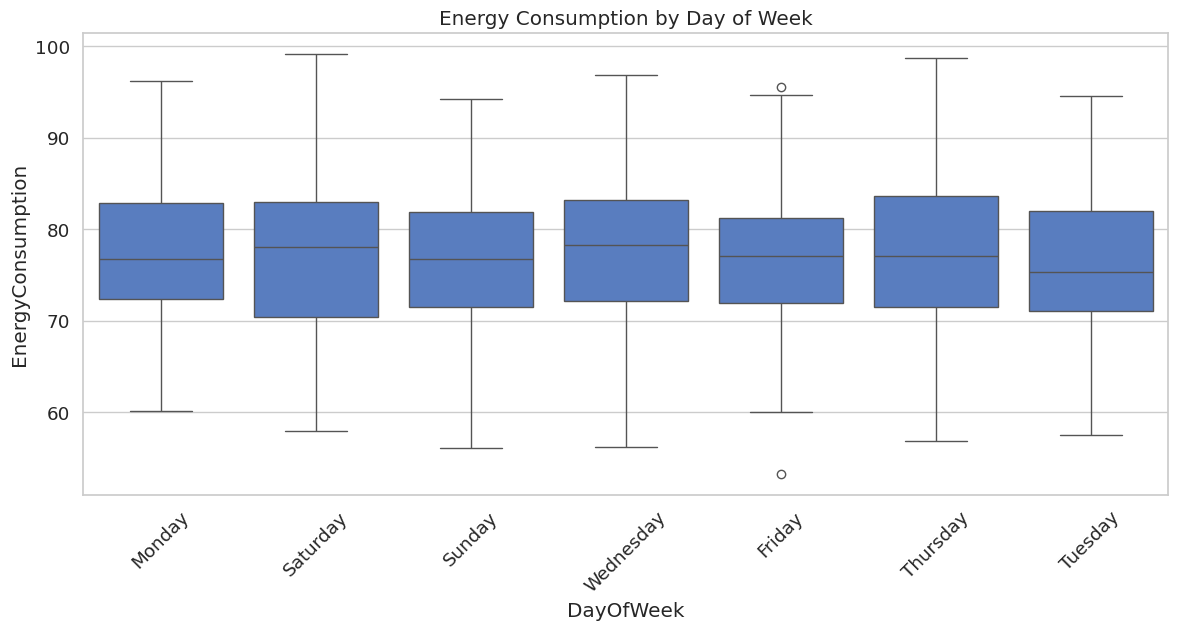

In [14]:
plt.figure(figsize=(14,6))
sns.boxplot(x='DayOfWeek', y='EnergyConsumption', data=df)
plt.title("Energy Consumption by Day of Week")
plt.xticks(rotation=45)
plt.show()

In [15]:

df = pd.get_dummies(df, columns=['HVACUsage', 'LightingUsage', 'DayOfWeek', 'Holiday'])

In [16]:

features = df.drop(columns=['Timestamp','EnergyConsumption'])
target = df['EnergyConsumption']

In [25]:
features.columns

Index(['Temperature', 'Humidity', 'SquareFootage', 'Occupancy',
       'RenewableEnergy', 'HVACUsage_Off', 'HVACUsage_On', 'LightingUsage_Off',
       'LightingUsage_On', 'DayOfWeek_Friday', 'DayOfWeek_Monday',
       'DayOfWeek_Saturday', 'DayOfWeek_Sunday', 'DayOfWeek_Thursday',
       'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday', 'Holiday_No',
       'Holiday_Yes'],
      dtype='object')

In [17]:
features.head()

,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,HVACUsage_Off,HVACUsage_On,LightingUsage_Off,LightingUsage_On,DayOfWeek_Friday,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,Holiday_No,Holiday_Yes
0,25.139433,43.431581,1565.693999,5,2.774699,False,True,True,False,False,True,False,False,False,False,False,True,False
1,27.731651,54.225919,1411.064918,1,21.831384,False,True,False,True,False,False,True,False,False,False,False,True,False
2,28.704277,58.907658,1755.715009,2,6.764672,True,False,True,False,False,False,False,True,False,False,False,True,False
3,20.080469,50.371637,1452.316318,1,8.623447,True,False,False,True,False,False,False,False,False,False,True,True,False
4,23.097359,51.401421,1094.130359,9,3.071969,False,True,True,False,True,False,False,False,False,False,False,True,False


In [18]:
target.head()

,EnergyConsumption
0,75.364373
1,83.401855
2,78.270888
3,56.519850
4,70.811732


In [19]:

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

features_scaled = scaler_X.fit_transform(features)
target_scaled = scaler_y.fit_transform(target.values.reshape(-1, 1))

In [20]:

split = int(0.9 * len(features_scaled))
X_train, X_test = features_scaled[:split], features_scaled[split:]
y_train, y_test = target_scaled[:split], target_scaled[split:]

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(900, 18) (100, 18) (900, 1) (100, 1)


In [21]:

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"RandomForest RMSE: {rmse_rf:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForest RMSE: 0.1161


In [22]:

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f"XGBoost RMSE: {rmse_xgb:.4f}")

XGBoost RMSE: 0.1266


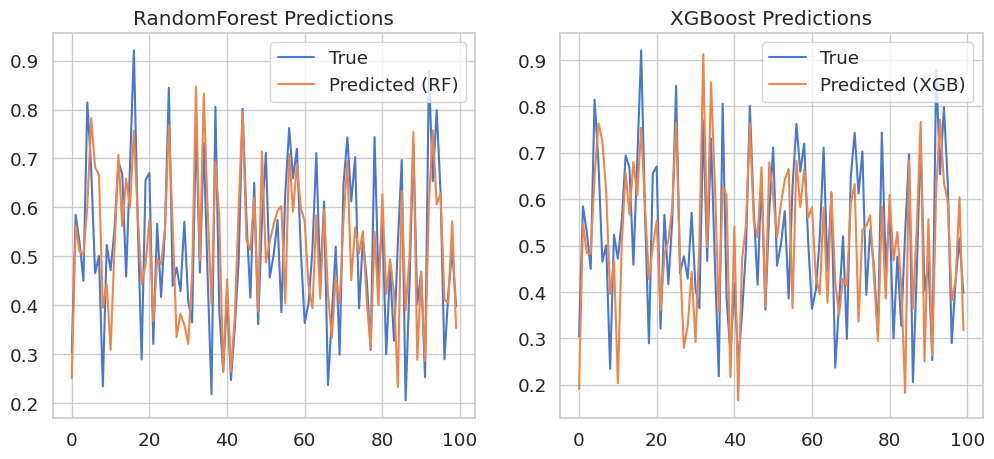

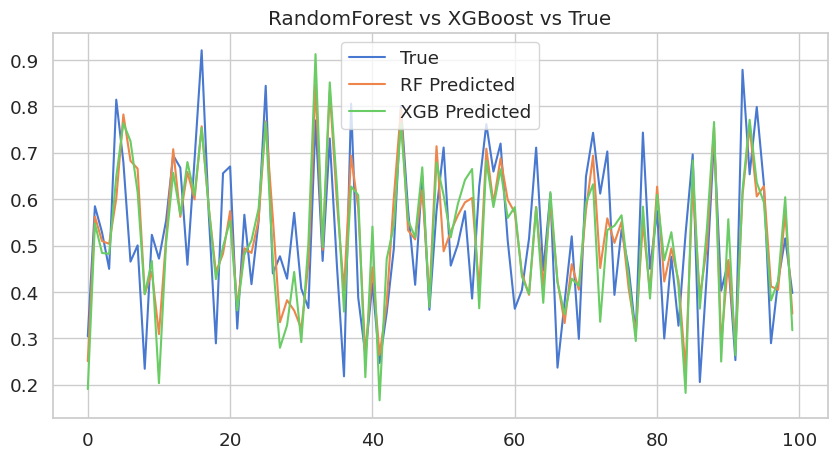

In [23]:

plt.figure(figsize=(12, 5))

# RandomForest
plt.subplot(1, 2, 1)
plt.plot(y_test, label="True")
plt.plot(y_pred_rf, label="Predicted (RF)")
plt.title("RandomForest Predictions")
plt.legend()

# XGBoost
plt.subplot(1, 2, 2)
plt.plot(y_test, label="True")
plt.plot(y_pred_xgb, label="Predicted (XGB)")
plt.title("XGBoost Predictions")
plt.legend()

plt.show()

# مقارنة في رسم واحد
plt.figure(figsize=(10, 5))
plt.plot(y_test, label="True")
plt.plot(y_pred_rf, label="RF Predicted")
plt.plot(y_pred_xgb, label="XGB Predicted")
plt.title("RandomForest vs XGBoost vs True")
plt.legend()
plt.show()


In [24]:
import joblib

# Save the best model (Random Forest)
joblib.dump(rf, 'best_rf_model.pkl')

# Save the scalers (CRITICAL for future predictions)
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

print("Model and scalers saved successfully!")

Model and scalers saved successfully!


In [26]:
import joblib
import pandas as pd
import numpy as np

# 1. Load the model and scalers
model = joblib.load('best_rf_model.pkl')
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')

# 2. Prepare new data (Ensure columns match the training set exactly)
# Example: Creating a single row of data based on your feature list
new_data = pd.DataFrame([{
    'Temperature': 22.5,
    'Humidity': 45.0,
    'SquareFootage': 1500,
    'Occupancy': 4,
    'RenewableEnergy': 0,
    'HVACUsage_Off': 0, 'HVACUsage_On': 1,
    'LightingUsage_Off': 0, 'LightingUsage_On': 1,
    'DayOfWeek_Friday': 0, 'DayOfWeek_Monday': 1, 'DayOfWeek_Saturday': 0,
    'DayOfWeek_Sunday': 0, 'DayOfWeek_Thursday': 0, 'DayOfWeek_Tuesday': 0,
    'DayOfWeek_Wednesday': 0,
    'Holiday_No': 1, 'Holiday_Yes': 0
}])

# 3. Scale the input features
new_data_scaled = scaler_X.transform(new_data)

# 4. Predict (Scaled output)
prediction_scaled = model.predict(new_data_scaled)

# 5. Inverse Transform (Back to actual Energy Consumption units)
# Note: We reshape because scaler_y expects a 2D array
prediction_actual = scaler_y.inverse_transform(prediction_scaled.reshape(-1, 1))

print(f"Predicted Energy Consumption: {prediction_actual[0][0]:.2f}")

Predicted Energy Consumption: 75.59


In [27]:
import pandas as pd
import joblib
import numpy as np

# Load your saved assets
model = joblib.load('best_rf_model.pkl')
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')

# Define the columns in the exact order the model expects
feature_names = [
    'Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy',
    'HVACUsage_Off', 'HVACUsage_On', 'LightingUsage_Off', 'LightingUsage_On',
    'DayOfWeek_Friday', 'DayOfWeek_Monday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday',
    'DayOfWeek_Thursday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday',
    'Holiday_No', 'Holiday_Yes'
]

# The data values you provided
raw_values = [
    25.1394, 33.4315, 811565.694, 9952.7747, False,
    True, True, False, False,
    False, True, False, False,
    False, False, False,
    True, False
]

# Create DataFrame (converting Booleans to 1/0 automatically)
input_df = pd.DataFrame([raw_values], columns=feature_names)

# --- THE PREDICTION PIPELINE ---

# 1. Scale inputs
X_scaled = scaler_X.transform(input_df)

# 2. Predict (returns scaled value)
y_pred_scaled = model.predict(X_scaled)

# 3. Inverse scale to get actual Energy Consumption
# Reshape is required because the scaler expects a 2D array [[value]]
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

print(f"Predicted Energy Consumption: {y_pred_actual[0][0]:.4f}")

Predicted Energy Consumption: 78.7603


In [28]:
import pandas as pd
import numpy as np
import joblib

# 1. Load the saved model and scalers
# (Make sure these files are in your current working directory)
model = joblib.load('best_rf_model.pkl')
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')

# 2. Define the exact feature names (MUST match your training set)
feature_names = [
    'Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy',
    'HVACUsage_Off', 'HVACUsage_On', 'LightingUsage_Off', 'LightingUsage_On',
    'DayOfWeek_Friday', 'DayOfWeek_Monday', 'DayOfWeek_Saturday', 'DayOfWeek_Sunday',
    'DayOfWeek_Thursday', 'DayOfWeek_Tuesday', 'DayOfWeek_Wednesday',
    'Holiday_No', 'Holiday_Yes'
]

def predict_energy(values_list):
    """
    Takes a list of 18 values, scales them, predicts, and inverse scales the result.
    """
    # Create DataFrame to maintain column order and handle Boolean conversion
    input_df = pd.DataFrame([values_list], columns=feature_names)

    # Ensure all data is numeric (converts True/False to 1/0)
    input_df = input_df.astype(float)

    # Scale the input features using the loaded scaler
    X_scaled = scaler_X.transform(input_df)

    # Generate prediction (this will be in the scaled 0-1 range)
    y_pred_scaled = model.predict(X_scaled)

    # Inverse transform to get the actual Energy Consumption value
    # .reshape(-1, 1) is required by the scaler
    y_pred_actual = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

    return y_pred_actual[0][0]

# --- EXAMPLE USAGE ---

# This is the data you just provided (18 elements)
new_data_points = [
    27.731651, 54.225919, 1411.064918, 121.831384, False,
    True, False, True, False,
    False, True, False, False,
    False, False, True,
    False, True
]

result = predict_energy(new_data_points)

print("-" * 30)
print(f"PREDICTED ENERGY CONSUMPTION: {result:.4f}")
print("-" * 30)

------------------------------
PREDICTED ENERGY CONSUMPTION: 80.1423
------------------------------


In [29]:
import pandas as pd

# 1. Convert the scaled X_test back into a readable DataFrame
# We use the original 'features.columns' to keep the headers correct
df_test_remaining = pd.DataFrame(X_test, columns=features.columns)

# 2. If you want to include the actual target (EnergyConsumption) in the Excel:
# We inverse transform y_test first so it's not a decimal between 0 and 1
y_test_actual = scaler_y.inverse_transform(y_test)
df_test_remaining['Actual_EnergyConsumption'] = y_test_actual

# 3. If you want to include the model's predictions in the Excel:
y_pred_rf_actual = scaler_y.inverse_transform(y_pred_rf.reshape(-1, 1))
df_test_remaining['Predicted_EnergyConsumption'] = y_pred_rf_actual

# 4. Export to Excel
output_file = "Remaining_Test_Features.xlsx"
df_test_remaining.to_excel(output_file, index=False)

print(f"File saved successfully as: {output_file}")

File saved successfully as: Remaining_Test_Features.xlsx


In [ ]:
from google.colab import drive
drive.mount('/content/drive')